In `fine-tuning transfer learning` the pre-trained model `weights` from another model are `unfrozen` and tweaked during to better suit your own data.

For `feature extraction transfer learning`, we may only train the top `1-3 layers` of a pre-trained model with the given dataset, in fine-tuning transfer learning, we might train 1-3+ layers of a pre-trained model (where the '+' indicates that many or all of the layers could be trained).

Feature extraction transfer learning vs. fine-tuning transfer learning. The main difference between the two is that in fine-tuning, more layers of the pre-trained model get unfrozen and tuned on custom data. This fine-tuning usually takes more data than feature extraction to be effective.



---

## Following Topics will be Covered.

* Introduce `fine-tuning`, a `type of transfer learning` to modify a pre-trained model to be more suited to the given dataset.

* Using the `Keras Functional API` (a differnt way to build models in Keras).

* Using a smaller dataset to experiment faster (e.g. 1-10% of training samples of 10 classes of food).

* `Data augmentation` (how to make training dataset more diverse without adding more data).

* Running a series of modelling experiments on our Food Vision data:
    
    * `Model 0:` a transfer learning model using the `Keras Functional API`.
    
    * `Model 1:` a feature extraction transfer learning model on 1% of the data with data augmentation.
    
    * `Model 2:` a feature extraction transfer learning model on 10% of the data with data augmentation.
    
    * `Model 3:` a fine-tuned transfer learning model on 10% of the data.
    
    * `Model 4:` a fine-tuned transfer learning model on 100% of the data.

* Introduce the `ModelCheckpoint callback` to save intermediate training results.

* Compare model experiments results using TensorBoard.
---

In [5]:
import datetime
print(f"Notebook Last run (end-to-end): {datetime.datetime.now()}")

Notebook Last run (end-to-end): 2025-02-16 23:34:09.487202


In [6]:
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.17.0


In [7]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


 ### Creating helper functions

In [9]:
# Get helper_functions.py script from course GitHub
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import helper functions we're going to use
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, walk_through_dir

zsh:1: command not found: wget


ModuleNotFoundError: No module named 'helper_functions'

### 10 Food Classes: Working with less data

In [ ]:
# Get 10% of the data of the 10 classes.
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

unzip_data("10_food_classes_10_percent.zip")

--2025-02-16 23:23:13--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.11.207, 172.217.204.207, 172.217.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.11.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   155MB/s    in 1.0s    

2025-02-16 23:23:14 (155 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [ ]:
# Walk through 10 percent data directory and list number of files
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent

In [ ]:
# Creating Training and Test directories.
train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

Since, as august 2023, the **ImageDataGenerator** class is **deprecated** and is not recommended to use in the future because is it very **slow** that's why.

Now, we can use this. `tf.keras.utils.image_dataset_from_directory()`

The above method expect the **file structure** in this below format:

**Example of file structure:-**


    10_food_classes_10_percent <- top level folder
    └───train <- training images
    │   └───pizza
    │   │   │   1008104.jpg
    │   │   │   1638227.jpg
    │   │   │   ...      
    │   └───steak
    │       │   1000205.jpg
    │       │   1647351.jpg
    │       │   ...
    │   
    └───test <- testing images
    │   └───pizza
    │   │   │   1001116.jpg
    │   │   │   1507019.jpg
    │   │   │   ...      
    │   └───steak
    │       │   100274.jpg
    │       │   1653815.jpg
    │       │   ...

One of the main benefits of using `tf.keras.prepreprocessing.image_dataset_from_directory()` rather than `ImageDataGenerator` is that it creates a `tf.data.Dataset` object rather than a `generator`.

The main advantage of this is the `tf.data.Dataset` **API** is much more efficient (faster) than the `ImageDataGenerator` **API** which is paramount for larger datasets.


In [ ]:
# Create data inputs.
import tensorflow as tf

IMAGE_SIZE = (224, 224)

# Taking only 10% of the data for the training.
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory = train_dir,
    image_size = IMAGE_SIZE,
    label_mode = "categorical", # types of labels.
    batch_size = 32
)

#
test_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=test_dir,
    image_size=IMAGE_SIZE,
    label_mode="categorical",
    batch_size=32
)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [ ]:
# Check the training data dataypes.
train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

* **(None, 224, 224, 3)** refers to the `tensor shape` of our images where **None** is the **batch size**, `224` is the `height` (and `width`) and `3` is the `color channels` (red, green, blue).
* **(None, 10)** refers to the **tensor shape** of the **labels** where **None** is the **batch size** and **10** is the **number of possible labels** (the 10 different food classes).

The `batch_size` is `None` due to **it only being used during model training**. We can think of None as a **placeholder waiting** to be filled with the **batch_size** parameter from **image_dataset_from_directory()**.

In [ ]:
# Check out the class names of our dataset.
train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [ ]:
# In order to see the batch of data.
for images, labels in train_data_10_percent.take(1):
    print(images, labels)

tf.Tensor(
[[[[2.95237560e+01 2.45237560e+01 5.52375650e+00]
   [3.18014984e+01 2.48014984e+01 6.80149889e+00]
   [3.04258614e+01 2.34258614e+01 5.42586088e+00]
   ...
   [7.23201370e+01 5.31058769e+01 3.97486687e+01]
   [7.23149185e+01 5.33149147e+01 3.93149147e+01]
   [7.59866409e+01 5.69866409e+01 4.19866409e+01]]

  [[2.90000000e+01 2.28883934e+01 4.44419670e+00]
   [2.98566647e+01 2.28566647e+01 4.85666466e+00]
   [2.99048138e+01 2.29048138e+01 4.90481520e+00]
   ...
   [7.33415375e+01 5.36905594e+01 4.16434975e+01]
   [7.41036301e+01 5.51036339e+01 4.11036339e+01]
   [7.39601364e+01 5.49601364e+01 4.05159416e+01]]

  [[2.90000000e+01 2.20000000e+01 4.00000000e+00]
   [2.90000000e+01 2.20000000e+01 4.00000000e+00]
   [3.01985016e+01 2.31985016e+01 5.19850159e+00]
   ...
   [7.54399338e+01 5.39842186e+01 4.29842186e+01]
   [7.67150574e+01 5.51345787e+01 4.19947357e+01]
   [7.60909729e+01 5.53045578e+01 4.19000282e+01]]

  ...

  [[3.87526817e+01 2.87526817e+01 1.88263512e+01]
   [4

Notice, How the image arrays come out as tensors of pixel values where as the labels come out as `one-hot encodings` (e.g. [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] for `hamburger`).

### **Model 0:** Building a **transfer learning model** using the **Keras Functional API.**

We're going to go through the following steps:

1. Instantiate a pre-trained base model object by choosing a target model such as `EfficientNetV2B0` from `tf.keras.applications.efficientnet_v2`, setting the include_top parameter to False (we do this because we're going to create our own top, which are the output layers for the model).

2. Set the base model's **trainable** attribute to **False** to freeze all of the weights in the pre-trained model.

3. Define an input layer for our model, for example, what shape of data should our model expect ?

4. [Optional] **Normalize** the inputs to our model if it requires. Some computer vision models such as `ResNetV250` require their inputs to be between `0` & `1`.

5. Pass the inputs to the base model.

6. Pool the outputs of the base model into a shape compatible with the output activation layer (turn base model output tensors into same shape as label tensors). This can be done using `tf.keras.layers.GlobalAveragePooling2D()` or `tf.keras.layers.GlobalMaxPooling2D()` though the former is more common in practice.

7. Create an output activation layer using `tf.keras.layers.Dense()` with the appropriate activation function and number of neurons.

8. Combine the inputs and outputs layer into a model using `tf.keras.Model()`.

9. Compile the model using the appropriate loss function and choose of optimizer.

10. Fit the model for desired number of epochs and with necessary callbacks (in our case, we'll start off with the TensorBoard callback).

In [ ]:
# 1. Create base model with `tf.keras.applications`
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False # this is because we will create our own output layer or top layer.
)

# 2. Freeze the base model (so the pre-learned patterns remains.)
base_model.trainable = False # Freeze all of the weights in the pre-trained models.

# 3. Create input layers into the base model.
inputs = tf.keras.layers.Input(
    shape = (224, 224, 3),
    name = "input_layer"
)

# 4. If using ResNet50V2, add this to speed up convergence, remove for EfficientNetV2.
# x = tf.keras.layers.experimental.preprocessing.Rescaling(1./255)(inputs)

# 5. Pass the inputs to the base_model (note: using tf.keras.applications, EfficientNetV2 inputs don't have to normalized.)
x = base_model(inputs)
# Check data shape after passing it to base_model.
print(f"Shape after base_model: {x.shape}")

# 6. Average Pool the outputs of the base model (aggregate all the most important information, reduce number of computations.)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"After GlobalAveragePooling2D(): {x.shape}")

# 7. Create the output activation layer.
outputs = tf.keras.layers.Dense(10, activation="softmax", name="output_layer")(x)

# 8. Combine the inputs with outputs into a model.
model_0 = tf.keras.Model(inputs, outputs)

# 9. Compile the Model.
model_0.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# 10. Fit the model (we use less steps for validation so it's faster).
history_10_percent = model_0.fit(
    train_data_10_percent,
    epochs=5,
    steps_per_epoch = len(train_data_10_percent),
    validation_data = test_data_10_percent,

    # Go through less of the Validation data so epochs are faster (we want faster experiments).
    validation_steps = int(0.25 * len(test_data_10_percent)),

    # Track our model's training logs for visualization later.
    callbacks = [create_tensorboard_callback("transfer_learning", "10_percent_feature_extract")]
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape after base_model: (None, 7, 7, 1280)
After GlobalAveragePooling2D(): (None, 1280)
Saving TensorBoard log files to: transfer_learning/10_percent_feature_extract/20250216-232323
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 102s 4s/step - accuracy: 0.2217 - loss: 2.1830 - val_accuracy: 0.7122 - val_loss: 1.3793
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.7257 - loss: 1.2919 - val_accuracy: 0.8125 - val_loss: 0.9078
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.8221 - loss: 0.8850 - val_accuracy: 0.8405 - val_loss: 0.7298
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8395 - loss: 0.7420 - val_accuracy: 0.8553 - val_loss: 0.6122
Epoch 5/5
12/24 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8664 - loss: 0.6108

> **Note:-** The kind of transfer learning that we just implemented is called `feature extraction transfer learning` which is similar what we have did in TensorFlow Hub Models.

In [ ]:
# Check layer in our base model.
for layer_number, layer in enumerate(base_model.layers):
    print(layer_number, layer.name)

In [ ]:
base_model.summary()

Since, we are implementing the Transfer Learning so that we can take parameters as a patterns in this case as the base model have learned on the another dataset.

In [ ]:
# Check the summary of model constructed with Functional API.
model_0.summary()

**Observation:**

* **Output shape:-** **(None, 224, 224, 3)** for the **Input Layer** But transformed to be **(None, 10)** by the **output layer** (the shape of our labels) where **None** is placeholder for the **batch size**.

In [ ]:
# Check out our model's training curves.
plot_loss_curves(history_10_percent)

### Getting a feature vector from a trained model

> 🤔 **Question:-** What happens with the **tf.keras.layers.GlobalAveragePooling2D()** layer ?

----> *The **tf.keras.layers.GlobalAveragePooling2D()** layer transforms a **4D tensor** into a **2D tensor** by **averaging** the values across the inner-axes.*

In [ ]:
# Define input tensor shape (same number of dimension as the output of efficientnetv2-b0).
input_shape = (1, 4, 4, 3)

# Create a random tensor.
tf.random.set_seed(42)

input_tensor = tf.random.normal(input_shape)
print(f"Random Input Tensor: \n {input_tensor}\n")

print(f"Number of dimension of input shape: {input_tensor.ndim}")

# Pass the random tensor through a global average pooling 2D layer.
global_average_pooled_tensor = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
print(f"2D Global Average pooled random tensor: \n {global_average_pooled_tensor}\n")

# Check the shapes of the different tensors.
print(f"Shape of input tensor: {input_tensor.shape}")
print(f"Shape of 2D global averaged pooled input tensor: {global_average_pooled_tensor.shape}")

**Observation**

We can see the `tf.keras.layers.GlobalAveragePooling2D()` layer condensed the `input tensor` from shape `(1, 4, 4, 3)` to `(1, 3)`. It did so by averaging the `input_tensor` across the `middle two axes`.

In [ ]:
# This is the same as GlobalAveragePooing2D()
tf.reduce_mean(input_tensor, axis=[1, 2]) # average across the middle axes.

> 🔑 **Note:** One of the reasons `feature extraction transfer learning` is named how it is is because what often happens is a pretrained model outputs a feature vector (a long tensor of numbers, in our case, this is the output of the `tf.keras.layers.GlobalAveragePooling2D()` layer) which can then be used to extract patterns out of.

In [ ]:
# Download and unzip data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
unzip_data("10_food_classes_1_percent.zip")

# Create training anbd test dirs.
train_dir_1_percent = "10_food_classes_1_percent/train/"
test_dir = "10_food_classes_1_percent/test/"

In [ ]:
# Walk through 1 percent data directory and list number of files.
walk_through_dir("10_food_classes_1_percent")

> 🔑 **Note:-** As with the **10%** of data subset, the **1%** of images were chosen at random from the original full training dataset. The test images are the same as the ones which have previously been used.

In [ ]:
# We will load our images in as tf.data.Dataset objects, to do so, we will use the  `image_dataset_from_directory()` method.
import tensorflow as tf

IMAGE_SIZE = (224, 224)

train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir_1_percent,
    label_mode="categorical",
    batch_size=32,
    image_size=IMAGE_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode="categorical",
    image_size=IMAGE_SIZE
)

### Adding data augmentation right into the model


Image data augmentation only happens during training so we can still export our whole model and use it elsewhere.

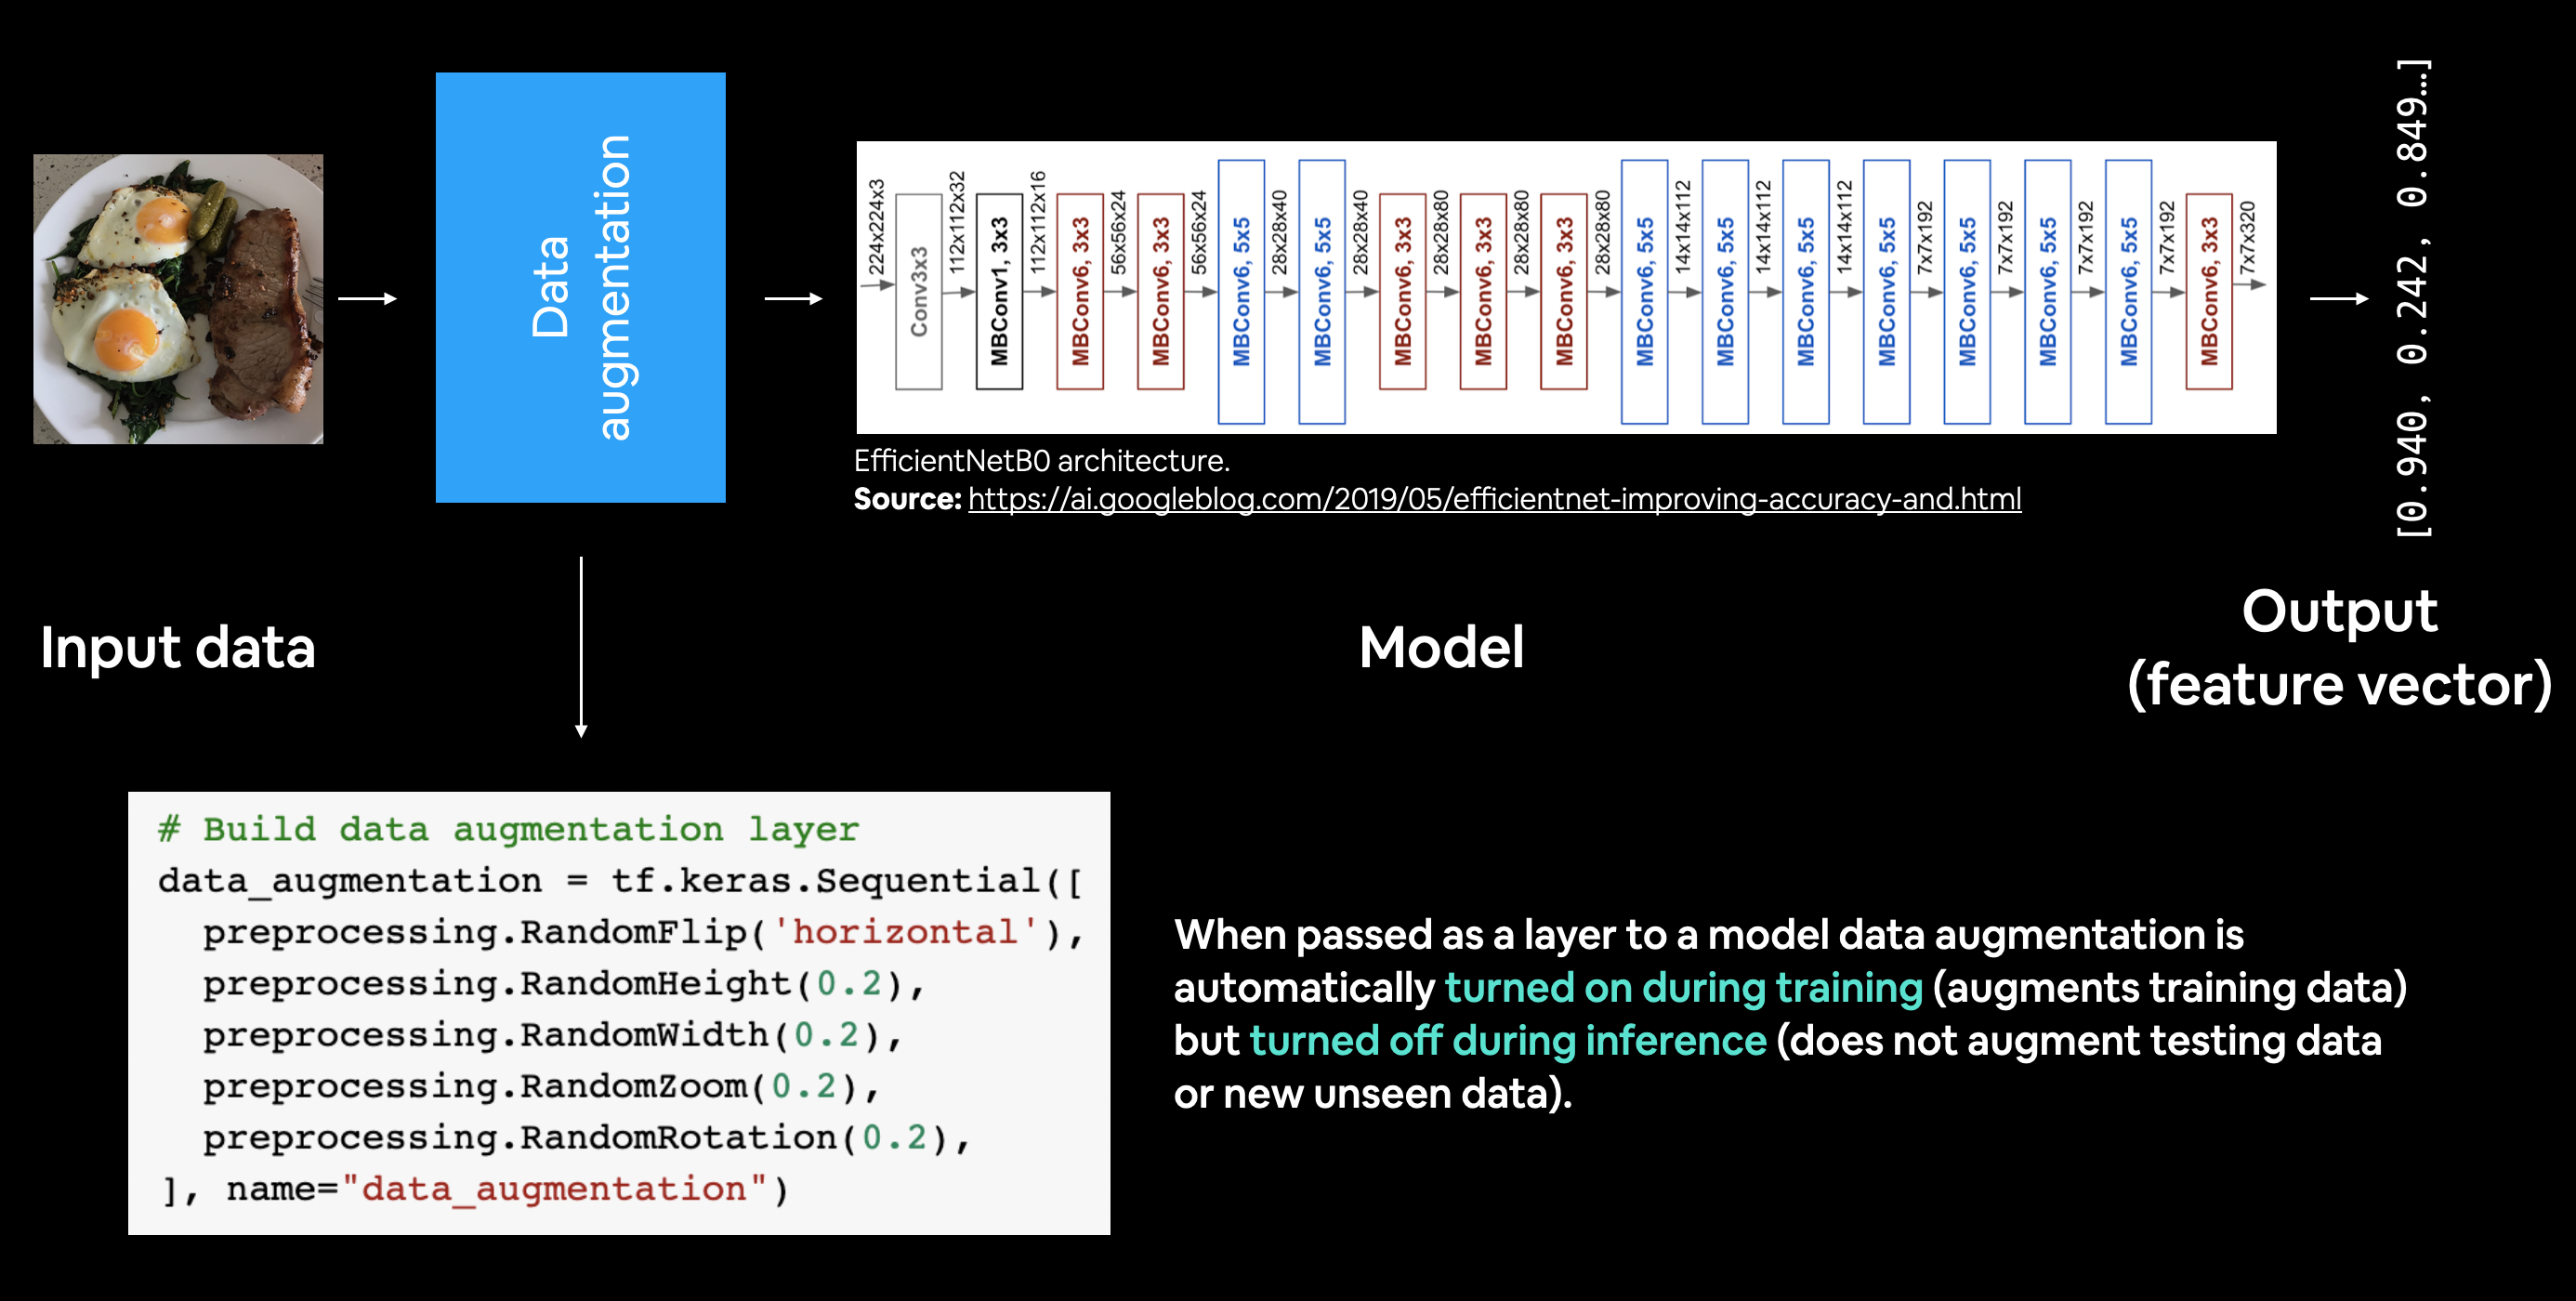

The data augmentation transformations we're going to use are:

* `tf.keras.layers.RandomFlip` - flips image on horizontal or vertical axis.
* `tf.keras.layersRandomRotation` - randomly rotates image by a specified amount.
* `tf.keras.layers.RandomZoom` - randomly zooms into an image by specified amount.
* `tf.keras.layers.RandomHeight` - randomly shifts image height by a specified amount.
* `tf.keras.layers.RandomWidth` - randomly shifts image width by a specified amount.
* `tf.keras.layers.Rescaling` - normalizes the image pixel values to be between 0 and 1, this is worth mentioning because it is required for some image models but since we're using `tf.keras.applications.efficientnet_v2.EfficientNetV2B0`, it's not required (the model pretrained model implements rescaling itself).

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# from tensorflow.keras.layers.experimental import preprocessing

# Implementing data augmentation layer.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2)
    # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetV2B0.
], name="data_augmentation")

In [ ]:
# View random image.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

target_class = random.choice(train_data_1_percent.class_names) # choose a random class.
target_dir = "10_food_classes_1_percent/train/" + target_class # create the target directory.

random_image = random.choice(os.listdir(target_dir)) # choose a random image from target directory.

random_image_path = target_dir + "/" + random_image # create the choosen random image path.

img = mpimg.imread(random_image_path) # read in the chosen target image.

plt.imshow(img) # Plot the target image.
plt.title(f"Original random image from class: {target_class}")
plt.axis(False); # Turn off the axes.

# Augment the Image.
augmented_img = data_augmentation(tf.expand_dims(img, axis=0)) # data augmentation model requires shape (None, height, width, 3).
plt.figure()
plt.imshow(tf.squeeze(augmented_img)/255.) # requires normalization after augmentation.
plt.title(f"Augmented random image from class: {target_class}")
plt.axis(False)

### **Model 1: Feature extraction transfer learning on 1% of the data with data augmentation.**

In [ ]:
# Setup input shape and base model, freezing the base model layers
input_shape = (224, 224, 3)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

# Create input layer
inputs = layers.Input(shape=input_shape, name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)

# Give base_model inputs (after augmentation) and don't train it
x = base_model(x, training=False)

# Pool output features of base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(10, activation="softmax", name="output_layer")(x)

# Make a model with inputs and outputs
model_1 = keras.Model(inputs, outputs)

# Compile the model
model_1.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_1_percent = model_1.fit(train_data_1_percent,
                    epochs=5,
                    steps_per_epoch=len(train_data_1_percent),
                    validation_data=test_data,
                    validation_steps=int(0.25* len(test_data)), # validate for less steps
                    # Track model training logs
                    callbacks=[create_tensorboard_callback("transfer_learning", "1_percent_data_aug")])

In [ ]:
# Check out model summary
model_1.summary()

> **Data augmentation only runs during training.** so if we were to evaluate or use our model for inference (predicting the class of an image) the `data augmentation` layers will be automatically turned off.

In [ ]:
# Evaluate on the test data.
results_1_percent_data_aug = model_1.evaluate(test_data)
results_1_percent_data_aug

In [ ]:
# Checking how this model go with a data augmentation layer with 1% of data.
plot_loss_curves(history_1_percent)

### **Model 2: Feature extraction transfer learning with 10% of data and data augmentation**

In [ ]:
# Get 10% of the data of the 10 classes (uncomment if you haven't gotten "10_food_classes_10_percent.zip" already)
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
# unzip_data("10_food_classes_10_percent.zip")

train_dir_10_percent = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

In [ ]:
# Setup data inputs.
import tensorflow as tf

IMAGE_SIZE = (224, 224)

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir_10_percent,
    label_mode="categorical",
    image_size=IMAGE_SIZE
)

# Note: the test data is the same as the previous experiment, we could skip creating this.
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode="categorical",
    image_size=IMAGE_SIZE
)

In [ ]:
# Create a functional model with data augmentation.
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers.experimental import preprocessing # OLD

# NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
  # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNet
], name ="data_augmentation")

# Setup the input shape to our model
input_shape = (224, 224, 3)

# Create a frozen base model
# base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

# Create input and output layers
inputs = layers.Input(shape=input_shape, name="input_layer") # create input layer
x = data_augmentation(inputs) # augment our training images
x = base_model(x, training=False) # pass augmented images to base model but keep it in inference mode, so batchnorm layers don't get updated: https://keras.io/guides/transfer_learning/#build-a-model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(10, activation="softmax", name="output_layer")(x)
model_2 = tf.keras.Model(inputs, outputs)

# Compile
model_2.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # use Adam optimizer with base learning rate
              metrics=["accuracy"])

In [ ]:
def create_base_model(input_shape: tuple[int, int, int] = (224, 224, 3),
                      output_shape: int = 10,
                      learning_rate: float = 0.001,
                      training: bool = False) -> tf.keras.Model:
    """
    Create a model based on EfficientNetV2B0 with built-in data augmentation.

    Parameters:
    - input_shape (tuple): Expected shape of input images. Default is (224, 224, 3).
    - output_shape (int): Number of classes for the output layer. Default is 10.
    - learning_rate (float): Learning rate for the Adam optimizer. Default is 0.001.
    - training (bool): Whether the base model is trainable. Default is False.

    Returns:
    - tf.keras.Model: The compiled model with specified input and output settings.
    """

    # Create base model
    base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
    base_model.trainable = training

    # Setup model input and outputs with data augmentation built-in
    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # pass augmented images to base model but keep it in inference mode
    x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
    outputs = layers.Dense(units=output_shape, activation="softmax", name="output_layer")(x)
    model = tf.keras.Model(inputs, outputs)

    # Compile model
    model.compile(loss="categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])

    return model

# Create an instance of model_2 with our new function
model_2 = create_base_model()

#### Creating a ModelCheckpoint callback

* We are going to introduce a new callback, the ModelCheckPoint callback.

* The `ModelCheckpoint callback` gives you the ability to save your model, as a whole in the `SavedModel` format or the `weights` (patterns) only to a specified directory as it trains.

If model is going to be training for a long time then we want to make backups for it as trains.

For example, say we fit a feature extraction transfer learning model for 5 epochs and check the training curves and see it was still improving and we want to see if fine-tuning for another 5 epochs could help, we can load the checkpoint, unfreeze some (or all) of the base model layers and then continue training.

In [ ]:
# We are going to introduce a new callback, the ModelCheckPoint callback.

# Setup Checkpoint path.
checkpoint_path = "ten_percent_model_checkpoints_weights/checkpoint.ckpt" # note: remember saving directly to Colab is temporary.


# Create a ModelCheckopoint callback that saves the model's weights only.
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True, # set to False to save the entire model
    save_best_only=True,# save only the best model weights instead of a model every epoch
    save_freq="epoch", # save every epoch
    verbose=1
)

> 🤔 Question: What's the difference between saving the entire model (SavedModel format) and saving the weights only?

The SavedModel format saves a model's architecture, weights and training configuration all in one folder. It makes it very easy to reload your model exactly how it is elsewhere. However, if you do not want to share all of these details with others, you may want to save and share the weights only (these will just be large tensors of non-human interpretable numbers). If disk space is an issue, saving the weights only is faster and takes up less space than saving the whole model.

Time to fit the model.

In [ ]:
# Fit the model saving checkpoints every epoch
initial_epochs = 5
history_10_percent_data_aug = model_2.fit(train_data_10_percent,
    epochs=initial_epochs,
    validation_data=test_data,
    validation_steps=int(0.25 * len(test_data)), # do less steps per validation (quicker)
    callbacks=[
        create_tensorboard_callback(
            "transfer_learning",
            "10_percent_data_aug"
            ),
    checkpoint_callback]
)

In [ ]:
# Evaluate on the test data
results_10_percent_data_aug = model_2.evaluate(test_data)
results_10_percent_data_aug

In [ ]:
# Plot model loss curves
plot_loss_curves(history_10_percent_data_aug)

In [ ]:
# Load in saved model weights and evaluate model
model_2.load_weights(checkpoint_path)
loaded_weights_model_results = model_2.evaluate(test_data)


In [ ]:
# If the results from our native model and the loaded weights are the same, this should output True
results_10_percent_data_aug == loaded_weights_model_results

In [ ]:
import numpy as np
# Check to see if loaded model results are very close to native model results (should output True)
np.isclose(np.array(results_10_percent_data_aug), np.array(loaded_weights_model_results))

In [ ]:
# Check the difference between the two results (small values)
print(np.array(results_10_percent_data_aug) - np.array(loaded_weights_model_results))